In [1]:
import sqlite3
import pandas as pd 
import numpy as np 

In [2]:
database = sqlite3.connect("database/customer_complaints.db")

query = "SELECT name FROM sqlite_master WHERE type='table';"

table = pd.read_sql_query(query, database)

print(table)

        name
0  complaint


In [3]:
df = pd.read_sql_query('SELECT * FROM complaint', database)

df.head()


,complaint_id,complaint_category,customer_id,customer_name,customer_country,communication_channel,complaint_description,complaint_product_type,complaint_priority,department_assigned,complaint_date,complaint_status
0,1,refund,1001,Customer_1,Nigeria,Email,I requested a refund for my Cleanser but have ...,Cleanser,2,Customer Support,2025-10-30,resolved
1,2,packaging,1002,Customer_2,Ghana,Mobile App,The Lipstick arrived with damaged packaging an...,Lipstick,1,Packaging Department,2025-04-23,resolved
2,3,product_quality,1003,Customer_3,Morocco,Phone Call,The Cleanser does not perform as advertised.,Cleanser,3,Quality Control Department,2025-04-21,resolved
3,4,packaging,1004,Customer_4,Algeria,Email,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-08-24,awaiting
4,5,packaging,1005,Customer_5,Algeria,Website,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-10-23,in_progress


In [4]:
count = pd.read_sql_query("SELECT COUNT(*) FROM complaint", database)
count

,COUNT(*)
0,508


In [5]:
distinct_complaint_id = pd.read_sql_query("SELECT COUNT(DISTINCT complaint_id) FROM complaint as total_distinct_complaints", database)
distinct_complaint_id

,COUNT(DISTINCT complaint_id)
0,500


In [6]:
distinct_complaint_category = pd.read_sql_query("SELECT COUNT(DISTINCT complaint_category) FROM complaint as total_distinct_category", database)
distinct_complaint_category

,COUNT(DISTINCT complaint_category)
0,6


In [7]:
distinct_customer_id = pd.read_sql_query("SELECT COUNT(DISTINCT customer_id) FROM complaint as distinct_customer_number", database)
distinct_customer_id

,COUNT(DISTINCT customer_id)
0,500


In [8]:
distinct_customer_name = pd.read_sql_query("SELECT COUNT(DISTINCT customer_name) FROM complaint as distinct_customer_names", database)
distinct_customer_name

,COUNT(DISTINCT customer_name)
0,500


In [9]:
distinct_customer_country = pd.read_sql_query("SELECT COUNT(DISTINCT customer_country) FROM complaint as distinct_customer_country", database)
distinct_customer_country

,COUNT(DISTINCT customer_country)
0,7


In [10]:
distinct_communication_channel = pd.read_sql_query("SELECT COUNT(DISTINCT communication_channel) FROM complaint as distinct_communication_channel", database)
distinct_communication_channel

,COUNT(DISTINCT communication_channel)
0,4


In [11]:
distinct_product_type = pd.read_sql_query("SELECT COUNT(DISTINCT complaint_product_type) FROM complaint as distict_product", database)
distinct_product_type

,COUNT(DISTINCT complaint_product_type)
0,11


In [12]:
distinct_priority = pd.read_sql_query("SELECT COUNT(DISTINCT complaint_priority) FROM complaint as distict_product", database)
distinct_priority

,COUNT(DISTINCT complaint_priority)
0,5


In [13]:
distinct_status = pd.read_sql_query("SELECT COUNT(DISTINCT complaint_status) FROM complaint as distict_status", database)
distinct_status

,COUNT(DISTINCT complaint_status)
0,3


In [14]:
distinct_department_assigned = pd.read_sql_query("SELECT COUNT(DISTINCT department_assigned) FROM complaint as distict_department", database)
distinct_department_assigned

,COUNT(DISTINCT department_assigned)
0,5


In [15]:
null_counts = pd.read_sql_query("""SELECT * FROM complaint WHERE 
complaint_id IS NULL OR complaint_category IS NULL OR 
customer_name Is NULL OR customer_id IS NULL OR customer_country IS NULL OR 
communication_channel IS NULL OR complaint_description IS NULL OR complaint_product_type IS NULL OR 
complaint_priority IS NULL OR department_assigned IS NULL OR 
complaint_date IS NULL OR complaint_status IS NULL""", database)
null_counts

,complaint_id,complaint_category,customer_id,customer_name,customer_country,communication_channel,complaint_description,complaint_product_type,complaint_priority,department_assigned,complaint_date,complaint_status
0,6,refund,1006,Customer_6,None,Phone Call,I requested a refund for my Cleanser but have ...,Cleanser,5,Customer Support,2025-02-21,resolved


In [16]:
country_null = pd.read_sql_query("SELECT customer_country FROM complaint WHERE customer_country IS NULL", database)
country_null

,customer_country
0,None


In [17]:
len(country_null)

1

In [18]:
date = pd.read_sql_query("SELECT complaint_date FROM complaint", database)
date

,complaint_date
0,2025-10-30
1,2025-04-23
2,2025-04-21
3,2025-08-24
4,2025-10-23
...,...
503,2025-11-15
504,2025-06-19
505,2025-08-24
506,2025-11-02


In [19]:
duplicates_count = pd.read_sql_query("""SELECT complaint_id, COUNT(*) AS compliant_count
FROM complaint
GROUP BY complaint_id
HAVING COUNT(*) > 1""", database)

duplicates_count

,complaint_id,compliant_count
0,32,2
1,48,2
2,68,2
3,305,2
4,311,2
5,341,2
6,480,2
7,486,2


In [20]:
# which category has the highest number of complaints
category_complaint_group = pd.read_sql_query("""SELECT complaint_category, COUNT(complaint_category) AS total_complaint_per_category, 
                                                (COUNT(complaint_id) * 100.0 / (SELECT COUNT(complaint_id) FROM complaint)) AS percentage_category
                                                FROM complaint
                                                GROUP BY complaint_category""", database)
category_complaint_group

,complaint_category,total_complaint_per_category,percentage_category
0,billing,51,10.039370
1,customer_service,75,14.763780
2,delivery,98,19.291339
3,packaging,103,20.275591
4,product_quality,116,22.834646
5,refund,65,12.795276


In [21]:
customer_country_group = pd.read_sql_query("""SELECT customer_country, COUNT(customer_country) AS total_customer_per_country, 
                                                (COUNT(complaint_id) * 100.0 / (SELECT COUNT(complaint_id) FROM complaint)) AS percentage_country
                                                FROM complaint
                                                GROUP BY customer_country
                                                ORDER BY total_customer_per_country DESC""", database)
customer_country_group

,customer_country,total_customer_per_country,percentage_country
0,Nigeria,91,17.913386
1,Morocco,77,15.157480
2,Ghana,76,14.960630
3,Algeria,72,14.173228
4,Egypt,71,13.976378
5,Kenya,61,12.007874
6,Tunisia,59,11.614173
7,NaN,0,0.196850


In [22]:
communication_channel_group = pd.read_sql_query("""SELECT communication_channel, COUNT(communication_channel) AS total_communication_channel, 
                                                (COUNT(complaint_id) * 100.0 / (SELECT COUNT(complaint_id) FROM complaint)) AS percentage_country
                                                FROM complaint
                                                GROUP BY communication_channel
                                                ORDER BY total_communication_channel DESC""", database)
communication_channel_group

,communication_channel,total_communication_channel,percentage_country
0,Website,128,25.19685
1,Phone Call,128,25.19685
2,Mobile App,126,24.80315
3,Email,126,24.80315


In [23]:
products_type = pd.read_sql_query("""SELECT complaint_product_type, COUNT(complaint_product_type) AS total_products, 
                                                (COUNT(complaint_id) * 100.0 / (SELECT COUNT(complaint_id) FROM complaint)) AS percentage_country
                                                FROM complaint
                                                GROUP BY complaint_product_type
                                                ORDER BY total_products DESC""", database)
products_type

,complaint_product_type,total_products,percentage_country
0,Kohl,65,12.795276
1,Lipstick,55,10.826772
2,Eyeliner,52,10.236220
3,Concealer,47,9.251969
4,Body Lotion,47,9.251969
5,Blush,46,9.055118
6,Sunscreen,44,8.661417
7,Primer,42,8.267717
8,Foundation,41,8.070866
9,Eyeshadow,39,7.677165


In [24]:
complaint_level = pd.read_sql_query("""SELECT complaint_priority, COUNT(complaint_priority) AS total_priority_count, 
                                                (COUNT(complaint_id) * 100.0 / (SELECT COUNT(complaint_id) FROM complaint)) AS percentage_country
                                                FROM complaint
                                                GROUP BY complaint_priority
                                                ORDER BY total_priority_count DESC""", database)
complaint_level

,complaint_priority,total_priority_count,percentage_country
0,3,169,33.267717
1,4,140,27.559055
2,2,98,19.291339
3,5,70,13.779528
4,1,31,6.102362


In [25]:
department_assigned = pd.read_sql_query("""SELECT department_assigned, COUNT(department_assigned) AS total_departments_counts, 
                                                (COUNT(complaint_id) * 100.0 / (SELECT COUNT(complaint_id) FROM complaint)) AS percentage_country
                                                FROM complaint
                                                GROUP BY department_assigned
                                                ORDER BY total_departments_counts DESC""", database)
department_assigned

,department_assigned,total_departments_counts,percentage_country
0,Customer Support,140,27.559055
1,Quality Control Department,116,22.834646
2,Packaging Department,103,20.275591
3,Delivery Department,98,19.291339
4,Finance Department,51,10.039370


In [26]:
complaint_status = pd.read_sql_query("""SELECT complaint_status, COUNT(complaint_status) AS total_complaints_status, 
                                                (COUNT(complaint_id) * 100.0 / (SELECT COUNT(complaint_id) FROM complaint)) AS percentage_country
                                                FROM complaint
                                                GROUP BY complaint_status
                                                ORDER BY total_complaints_status DESC""", database)
complaint_status

,complaint_status,total_complaints_status,percentage_country
0,resolved,181,35.629921
1,awaiting,170,33.464567
2,in_progress,157,30.905512


In [27]:
create_new_database = pd.read_sql_query("""WITH new_customer_complaints AS (
SELECT 
DISTINCT(complaint_id) AS new_complaint_id,
TRIM(complaint_category) as new_complaint_category,
customer_id AS new_customer_id, 
customer_name AS new_customer_name,
TRIM(customer_country) AS new_customer_country,
TRIM(communication_channel) AS new_communication_channel,
complaint_description AS new_complaint_description,
TRIM(complaint_product_type) AS new_complaint_product_type,
TRIM(complaint_priority) AS new_complaint_priority,
TRIM(department_assigned) AS new_department_assigend,
CASE
    WHEN complaint_date LIKE "____-__-__" THEN complaint_date
    ELSE date(complaint_date) END AS new_complaint_date,
complaint_status AS new_complaint_status
FROM complaint
)
SELECT * FROM new_customer_complaints""", database)
create_new_database
create_new_database.to_csv("customer_complaints.csv", index=False)

In [28]:
customer_complaints  = pd.read_csv("customer_complaints.csv")
customer_complaints_data = customer_complaints.copy()
customer_complaints_data.head()

,new_complaint_id,new_complaint_category,new_customer_id,new_customer_name,new_customer_country,new_communication_channel,new_complaint_description,new_complaint_product_type,new_complaint_priority,new_department_assigend,new_complaint_date,new_complaint_status
0,1,refund,1001,Customer_1,Nigeria,Email,I requested a refund for my Cleanser but have ...,Cleanser,2,Customer Support,2025-10-30,resolved
1,2,packaging,1002,Customer_2,Ghana,Mobile App,The Lipstick arrived with damaged packaging an...,Lipstick,1,Packaging Department,2025-04-23,resolved
2,3,product_quality,1003,Customer_3,Morocco,Phone Call,The Cleanser does not perform as advertised.,Cleanser,3,Quality Control Department,2025-04-21,resolved
3,4,packaging,1004,Customer_4,Algeria,Email,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-08-24,awaiting
4,5,packaging,1005,Customer_5,Algeria,Website,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-10-23,in_progress


In [29]:
customer_complaints_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   new_complaint_id            500 non-null    int64
 1   new_complaint_category      500 non-null    str  
 2   new_customer_id             500 non-null    int64
 3   new_customer_name           500 non-null    str  
 4   new_customer_country        499 non-null    str  
 5   new_communication_channel   500 non-null    str  
 6   new_complaint_description   500 non-null    str  
 7   new_complaint_product_type  500 non-null    str  
 8   new_complaint_priority      500 non-null    int64
 9   new_department_assigend     500 non-null    str  
 10  new_complaint_date          500 non-null    str  
 11  new_complaint_status        500 non-null    str  
dtypes: int64(3), str(9)
memory usage: 115.8 KB


In [30]:
customer_complaints_data['new_complaint_description'].head()

0    I requested a refund for my Cleanser but have ...
1    The Lipstick arrived with damaged packaging an...
2         The Cleanser does not perform as advertised.
3    the body lotion arrived with damaged packaging...
4    the body lotion arrived with damaged packaging...
Name: new_complaint_description, dtype: str

In [31]:
customer_complaints_data['new_complaint_description'].describe()

count                                          500
unique                                         132
top       The Kohl does not perform as advertised.
freq                                            13
Name: new_complaint_description, dtype: object

In [32]:
customer_complaints_data['complaints_description_length'] = customer_complaints_data['new_complaint_description'].str.len()

In [33]:
customer_complaints_data.head()

,new_complaint_id,new_complaint_category,new_customer_id,new_customer_name,new_customer_country,new_communication_channel,new_complaint_description,new_complaint_product_type,new_complaint_priority,new_department_assigend,new_complaint_date,new_complaint_status,complaints_description_length
0,1,refund,1001,Customer_1,Nigeria,Email,I requested a refund for my Cleanser but have ...,Cleanser,2,Customer Support,2025-10-30,resolved,62
1,2,packaging,1002,Customer_2,Ghana,Mobile App,The Lipstick arrived with damaged packaging an...,Lipstick,1,Packaging Department,2025-04-23,resolved,66
2,3,product_quality,1003,Customer_3,Morocco,Phone Call,The Cleanser does not perform as advertised.,Cleanser,3,Quality Control Department,2025-04-21,resolved,44
3,4,packaging,1004,Customer_4,Algeria,Email,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-08-24,awaiting,69
4,5,packaging,1005,Customer_5,Algeria,Website,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-10-23,in_progress,69


In [34]:
customer_complaints_data['complaints_description_length'].describe()

count    500.000000
mean      57.758000
std       12.172912
min       40.000000
25%       46.000000
50%       59.000000
75%       67.000000
max       92.000000
Name: complaints_description_length, dtype: float64

In [35]:
lowest_lenght_column = customer_complaints_data[customer_complaints_data['complaints_description_length'] == 40 ]
len(lowest_lenght_column)

14

In [36]:
lowest_lenght_column.head(14)

,new_complaint_id,new_complaint_category,new_customer_id,new_customer_name,new_customer_country,new_communication_channel,new_complaint_description,new_complaint_product_type,new_complaint_priority,new_department_assigend,new_complaint_date,new_complaint_status,complaints_description_length
19,20,product_quality,1020,Customer_20,Nigeria,Phone Call,The Kohl does not perform as advertised.,Kohl,3,Quality Control Department,2025-04-26,in_progress,40
34,35,product_quality,1035,Customer_35,Ghana,Website,The Kohl does not perform as advertised.,Kohl,4,Quality Control Department,2025-03-01,in_progress,40
130,131,product_quality,1131,Customer_131,Nigeria,Mobile App,The Kohl does not perform as advertised.,Kohl,2,Quality Control Department,2025-02-16,awaiting,40
143,144,product_quality,1144,Customer_144,Nigeria,Website,The Kohl does not perform as advertised.,Kohl,5,Quality Control Department,2025-11-04,resolved,40
173,174,product_quality,1174,Customer_174,Algeria,Mobile App,The Kohl does not perform as advertised.,Kohl,4,Quality Control Department,2025-04-30,awaiting,40
184,185,product_quality,1185,Customer_185,Egypt,Email,The Kohl does not perform as advertised.,Kohl,3,Quality Control Department,2025-07-19,resolved,40
198,199,product_quality,1199,Customer_199,Ghana,Mobile App,The Kohl does not perform as advertised.,Kohl,1,Quality Control Department,2025-09-23,resolved,40
259,260,product_quality,1260,Customer_260,Tunisia,Phone Call,The Kohl does not perform as advertised.,Kohl,5,Quality Control Department,2025-07-31,resolved,40
298,299,product_quality,1299,Customer_299,Kenya,Mobile App,The Kohl does not perform as advertised.,Kohl,2,Quality Control Department,2025-02-07,resolved,40
303,304,product_quality,1304,Customer_304,Nigeria,Mobile App,The Kohl does not perform as advertised.,Kohl,3,Quality Control Department,2025-02-23,resolved,40


In [37]:
customer_complaints_data

,new_complaint_id,new_complaint_category,new_customer_id,new_customer_name,new_customer_country,new_communication_channel,new_complaint_description,new_complaint_product_type,new_complaint_priority,new_department_assigend,new_complaint_date,new_complaint_status,complaints_description_length
0,1,refund,1001,Customer_1,Nigeria,Email,I requested a refund for my Cleanser but have ...,Cleanser,2,Customer Support,2025-10-30,resolved,62
1,2,packaging,1002,Customer_2,Ghana,Mobile App,The Lipstick arrived with damaged packaging an...,Lipstick,1,Packaging Department,2025-04-23,resolved,66
2,3,product_quality,1003,Customer_3,Morocco,Phone Call,The Cleanser does not perform as advertised.,Cleanser,3,Quality Control Department,2025-04-21,resolved,44
3,4,packaging,1004,Customer_4,Algeria,Email,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-08-24,awaiting,69
4,5,packaging,1005,Customer_5,Algeria,Website,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-10-23,in_progress,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,packaging,1496,Customer_496,Kenya,Website,the kohl arrived with damaged packaging and i ...,Kohl,4,Packaging Department,2025-07-02,in_progress,62
496,497,refund,1497,Customer_497,Morocco,Mobile App,i requested a refund for my sunscreen but have...,Sunscreen,5,Customer Support,2025-08-19,resolved,63
497,498,refund,1498,Customer_498,Algeria,Website,I requested a refund for my Eyeliner but have ...,Eyeliner,3,Customer Support,2025-08-08,in_progress,62
498,499,packaging,1499,Customer_499,Morocco,Website,The Sunscreen arrived with damaged packaging a...,Sunscreen,4,Packaging Department,2025-03-10,awaiting,67


In [38]:
customer_complaints_data['cleaned_complaints'] = customer_complaints_data['new_complaint_description'].str.lower().str.replace(r'[^\w\s]', "", regex=True)

In [39]:
customer_complaints_data['cleaned_complaints'].head()

0    i requested a refund for my cleanser but have ...
1    the lipstick arrived with damaged packaging an...
2          the cleanser does not perform as advertised
3    the body lotion arrived with damaged packaging...
4    the body lotion arrived with damaged packaging...
Name: cleaned_complaints, dtype: str

In [40]:
customer_complaints_data[['new_complaint_description', 'cleaned_complaints']].head()

,new_complaint_description,cleaned_complaints
0,I requested a refund for my Cleanser but have ...,i requested a refund for my cleanser but have ...
1,The Lipstick arrived with damaged packaging an...,the lipstick arrived with damaged packaging an...
2,The Cleanser does not perform as advertised.,the cleanser does not perform as advertised
3,the body lotion arrived with damaged packaging...,the body lotion arrived with damaged packaging...
4,the body lotion arrived with damaged packaging...,the body lotion arrived with damaged packaging...


In [41]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(stop_words)

{'for', 'y', 'aren', 'ourselves', 'through', 'we', 'yourselves', 'or', 'so', 'down', 'above', 'theirs', 'hadn', 'other', "don't", "haven't", 'these', 'it', 'how', 'hasn', 'out', "they're", 'each', 'before', 'just', "doesn't", "they'll", 'why', 'mustn', 'he', 'than', 'some', 'doing', 'were', 'do', 'then', "we'll", 'mightn', 'again', 'at', 'been', "that'll", 'who', 'they', 'more', 'o', "she'd", "wasn't", 'once', 'can', "mightn't", 't', 'there', 'ma', 'shan', "they've", 'our', "i've", 'weren', 'yours', 'have', 'couldn', 'in', 'yourself', 'until', 'ours', 'needn', "i'm", 'does', 'him', 'will', 'are', "i'd", "we'd", "should've", "shouldn't", "he'd", 'that', 'wouldn', "wouldn't", 'me', 'your', 'ain', 'having', "he's", 'during', 's', 'd', 'did', 'nor', 'and', "it'll", 've', 'haven', 'not', 'on', 'now', 'both', "aren't", 'an', 'my', "she's", "he'll", 'below', "didn't", 'same', 'll', 'isn', 'most', 'to', "it's", "mustn't", 'of', 'should', 'i', 'where', 'don', 'wasn', 'those', 'all', "you'd", "i

[nltk_data] Downloading package stopwords to C:\Users\Khadija
[nltk_data]     Ismail\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [42]:
import joblib
joblib.dump(stopwords, "stop_words.pkl")

['stop_words.pkl']

In [43]:
def remove_stop_words(text):
    words = text.split()

    filtered_words = [word for word in words if word not in stop_words]

    return " ".join(filtered_words)
    
customer_complaints_data['cleaned_complaints'] = customer_complaints_data['cleaned_complaints'].apply(remove_stop_words)

customer_complaints_data[['cleaned_complaints', "new_complaint_description"]].head()

,cleaned_complaints,new_complaint_description
0,requested refund cleanser received,I requested a refund for my Cleanser but have ...
1,lipstick arrived damaged packaging disappointed,The Lipstick arrived with damaged packaging an...
2,cleanser perform advertised,The Cleanser does not perform as advertised.
3,body lotion arrived damaged packaging disappoi...,the body lotion arrived with damaged packaging...
4,body lotion arrived damaged packaging disappoi...,the body lotion arrived with damaged packaging...


In [44]:
# to count the most frequents word that appear in the cleaned_complaints_column
from collections import Counter

combined_words = " ".join(customer_complaints_data['cleaned_complaints'])
all_words = combined_words.split()
count_words = Counter(all_words)
top_20_words = count_words.most_common(20)

for word, count in top_20_words:
    print(f"{word} : {count}")


arrived : 200
received : 137
perform : 112
advertised : 112
damaged : 102
packaging : 102
disappointed : 102
order : 98
much : 98
later : 98
expected : 98
contacted : 74
support : 74
never : 74
helpful : 74
response : 74
kohl : 64
requested : 63
refund : 63
lipstick : 54


In [45]:
from nltk import ngrams


ngrams_count = ngrams(all_words, 2)

bigrams_wordcount = Counter(ngrams_count)

top_20_ngrams = bigrams_wordcount.most_common(20)

top_20_ngrams

for word, count in top_20_ngrams:
    print(f"{word} : {count}")



('perform', 'advertised') : 112
('arrived', 'damaged') : 102
('damaged', 'packaging') : 102
('packaging', 'disappointed') : 102
('order', 'arrived') : 98
('arrived', 'much') : 98
('much', 'later') : 98
('later', 'expected') : 98
('contacted', 'support') : 74
('never', 'received') : 74
('received', 'helpful') : 74
('helpful', 'response') : 74
('requested', 'refund') : 63
('charged', 'twice') : 51
('body', 'lotion') : 46
('please', 'help') : 35
('expected', 'requested') : 16
('advertised', 'contacted') : 15
('eyeliner', 'order') : 15
('response', 'contacted') : 14


In [46]:
list(customer_complaints_data)

['new_complaint_id',
 'new_complaint_category',
 'new_customer_id',
 'new_customer_name',
 'new_customer_country',
 'new_communication_channel',
 'new_complaint_description',
 'new_complaint_product_type',
 'new_complaint_priority',
 'new_department_assigend',
 'new_complaint_date',
 'new_complaint_status',
 'complaints_description_length',
 'cleaned_complaints']

In [47]:
# to check for different lenghts of complaints base on the category

category_grouping = customer_complaints_data.groupby('new_complaint_category')['complaints_description_length'].mean().sort_values(ascending=False)
print(category_grouping)


new_complaint_category
customer_service    76.378378
packaging           66.578431
refund              62.888889
delivery            52.469388
billing             46.156863
product_quality     44.446429
Name: complaints_description_length, dtype: float64


In [48]:
customer_complaints_data.to_csv("data/new_customer_complaints.csv", index=False)

In [49]:
# create a new column to count the words lenght from the complaint_description column
customer_complaints_data['complaint_description_word_count'] = customer_complaints_data['new_complaint_description'].str.split().str.len()

In [50]:
customer_complaints_data['char_per_word'] = customer_complaints_data['complaints_description_length'] / customer_complaints_data['complaint_description_word_count']


In [51]:
customer_complaints_data['exclamation_count'] = customer_complaints_data['new_complaint_description'].str.count("!")

In [52]:
customer_complaints_data[['new_complaint_description', "complaints_description_length", "complaint_description_word_count", "char_per_word", "exclamation_count"]].sample(20)

,new_complaint_description,complaints_description_length,complaint_description_word_count,char_per_word,exclamation_count
392,The Primer arrived with damaged packaging and ...,64,10,6.400000,0
468,I was charged twice for my Concealer purchase.,46,8,5.750000,0
388,The Cleanser arrived with damaged packaging an...,66,10,6.600000,0
455,The Blush arrived with damaged packaging and I...,78,12,6.500000,3
138,My Kohl order arrived much later than expected.,47,8,5.875000,0
141,I requested a refund for my Eyeshadow but have...,63,12,5.250000,0
163,My Primer order arrived much later than expected.,49,8,6.125000,0
161,The Blush arrived with damaged packaging and I...,78,12,6.500000,3
251,I was charged twice for my Sunscreen purchase....,61,10,6.100000,3
402,The Concealer does not perform as advertised.,45,7,6.428571,0


In [53]:
customer_complaints_data["lower_case_cleaned_description"] = customer_complaints_data['new_complaint_description'].str.lower().str.replace(r'[^\w\s]', "", regex=True)

In [54]:
# the model building phase
# Baseline model the multimodal baseline model
cleaned_data = pd.read_csv("data/new_customer_complaints.csv")
cleaned_data.head()

,new_complaint_id,new_complaint_category,new_customer_id,new_customer_name,new_customer_country,new_communication_channel,new_complaint_description,new_complaint_product_type,new_complaint_priority,new_department_assigend,new_complaint_date,new_complaint_status,complaints_description_length,cleaned_complaints
0,1,refund,1001,Customer_1,Nigeria,Email,I requested a refund for my Cleanser but have ...,Cleanser,2,Customer Support,2025-10-30,resolved,62,requested refund cleanser received
1,2,packaging,1002,Customer_2,Ghana,Mobile App,The Lipstick arrived with damaged packaging an...,Lipstick,1,Packaging Department,2025-04-23,resolved,66,lipstick arrived damaged packaging disappointed
2,3,product_quality,1003,Customer_3,Morocco,Phone Call,The Cleanser does not perform as advertised.,Cleanser,3,Quality Control Department,2025-04-21,resolved,44,cleanser perform advertised
3,4,packaging,1004,Customer_4,Algeria,Email,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-08-24,awaiting,69,body lotion arrived damaged packaging disappoi...
4,5,packaging,1005,Customer_5,Algeria,Website,the body lotion arrived with damaged packaging...,Body Lotion,4,Packaging Department,2025-10-23,in_progress,69,body lotion arrived damaged packaging disappoi...


In [55]:
cleaned_data = pd.read_csv('data/new_customer_complaints.csv')
cleaned_data['lower_case_cleaned_description'] = cleaned_data['new_complaint_description'].str.strip().str.lower().replace(r"r[\n\w]", "", regex=True)

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, recall_score, ConfusionMatrixDisplay

X = cleaned_data['lower_case_cleaned_description']
y = cleaned_data['new_complaint_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.3)

X_train.shape
# (350,)
X_test.shape
# (150,)
y_test.shape
# (150,)
y_train.shape
# (350,)

(350,)

In [57]:
type(y)

pandas.Series

In [58]:
# to check for equal category distrbution
target_distribution = pd.DataFrame({
    "Train" : y_train.value_counts(normalize=True) * 100,
    "Test" : y_test.value_counts(normalize=True) * 100
})
target_distribution

,Train,Test
new_complaint_category,,
product_quality,22.285714,22.666667
packaging,20.285714,20.666667
delivery,19.714286,19.333333
customer_service,14.857143,14.666667
refund,12.571429,12.666667
billing,10.285714,10.000000


In [59]:
vectoriser = CountVectorizer()

X_train_vectorise = vectoriser.fit_transform(X_train)
X_test_vectorise = vectoriser.transform(X_test)

print(X_train_vectorise.shape)
print(X_test_vectorise.shape)

(350, 50)
(150, 50)


In [60]:
type(X_test_vectorise)

scipy.sparse._csr.csr_matrix

In [61]:
learned_words = vectoriser.get_feature_names_out()
learned_words

array(['about', 'adveised', 'aived', 'am', 'and', 'as', 'blush', 'body',
       'but', 'ceived', 'chaed', 'cleanser', 'concealer', 'contacted',
       'damaged', 'disappointed', 'does', 'expected', 'eyeliner',
       'eyeshadow', 'for', 'foundation', 'fund', 'have', 'help',
       'helpful', 'it', 'kohl', 'later', 'lipstick', 'lotion', 'much',
       'my', 'never', 'not', 'oer', 'packaging', 'peo', 'please', 'pmer',
       'puhase', 'quested', 'sponse', 'sunscen', 'suppo', 'than', 'the',
       'twice', 'was', 'with'], dtype=object)

In [62]:
len_words = len(learned_words)
print("The total number of the words are:")
print(len_words)
print("The Top 20 are:")
print(learned_words[:20])

The total number of the words are:
50
The Top 20 are:
['about' 'adveised' 'aived' 'am' 'and' 'as' 'blush' 'body' 'but' 'ceived'
 'chaed' 'cleanser' 'concealer' 'contacted' 'damaged' 'disappointed'
 'does' 'expected' 'eyeliner' 'eyeshadow']


In [63]:
# to train the model 
model = MultinomialNB()
model.fit(X_train_vectorise, y_train)

y_pred = model.predict(X_test_vectorise)
y_pred_proba = model.predict_proba(X_test_vectorise)
print(y_pred.shape)
type(y_pred)

print(y_pred[:20])
y_pred_proba[:5]

(150,)
['delivery' 'product_quality' 'customer_service' 'packaging'
 'customer_service' 'delivery' 'product_quality' 'packaging'
 'customer_service' 'product_quality' 'refund' 'customer_service'
 'packaging' 'packaging' 'refund' 'delivery' 'packaging' 'product_quality'
 'product_quality' 'packaging']


array([[1.69419739e-09, 4.91000912e-12, 9.99999998e-01, 1.30367960e-11,
        9.09623044e-13, 3.36233896e-11],
       [8.04669947e-11, 2.58675122e-12, 4.34639434e-12, 9.73718384e-11,
        1.00000000e+00, 3.08374792e-10],
       [1.84807888e-12, 1.00000000e+00, 2.44194824e-14, 6.43827402e-15,
        4.62938720e-16, 1.36230169e-12],
       [9.07609302e-13, 2.36550845e-13, 3.61968798e-13, 1.00000000e+00,
        4.45118064e-13, 1.29590655e-14],
       [4.22418029e-12, 1.00000000e+00, 2.30240834e-14, 5.51852059e-15,
        3.60731470e-16, 2.04345253e-12]])

In [64]:
show_accuracy = accuracy_score(y_test, y_pred)
show_precision = precision_score(y_test, y_pred, average="weighted")
show_f1score = f1_score(y_test, y_pred, average="weighted")
show_recall = recall_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)
clas_report = classification_report(y_test, y_pred)

print(f"Accuracy Score: {show_accuracy}")
print(f"Precision Score: {show_precision}")
print(f"F1 Score: {show_f1score}")
print(f"Recall Score: {show_recall}")
print("confusion Matrix")
print(cm)

# Accuracy Score: 1.0
# Precision Score: 1.0
# F1 Score: 1.0
# Recall Score: 1.0
# confusion Matrix
# [[15  0  0  0  0  0]
#  [ 0 22  0  0  0  0]
#  [ 0  0 29  0  0  0]
#  [ 0  0  0 31  0  0]
#  [ 0  0  0  0 34  0]
#  [ 0  0  0  0  0 19]]


Accuracy Score: 1.0
Precision Score: 1.0
F1 Score: 1.0
Recall Score: 1.0
confusion Matrix
[[15  0  0  0  0  0]
 [ 0 22  0  0  0  0]
 [ 0  0 29  0  0  0]
 [ 0  0  0 31  0  0]
 [ 0  0  0  0 34  0]
 [ 0  0  0  0  0 19]]


In [65]:
print("Classification_Report")
print(clas_report)

# Classification_Report
#                   precision    recall  f1-score   support

#          billing       1.00      1.00      1.00        15
# customer_service       1.00      1.00      1.00        22
#         delivery       1.00      1.00      1.00        29
#        packaging       1.00      1.00      1.00        31
#  product_quality       1.00      1.00      1.00        34
#           refund       1.00      1.00      1.00        19

#         accuracy                           1.00       150
#        macro avg       1.00      1.00      1.00       150
#     weighted avg       1.00      1.00      1.00       150

Classification_Report
                  precision    recall  f1-score   support

         billing       1.00      1.00      1.00        15
customer_service       1.00      1.00      1.00        22
        delivery       1.00      1.00      1.00        29
       packaging       1.00      1.00      1.00        31
 product_quality       1.00      1.00      1.00        34
          refund       1.00      1.00      1.00        19

        accuracy                           1.00       150
       macro avg       1.00      1.00      1.00       150
    weighted avg       1.00      1.00      1.00       150



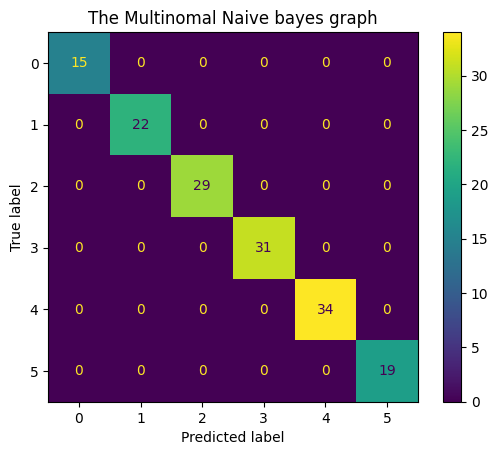

In [66]:
import matplotlib.pyplot as plt

display = ConfusionMatrixDisplay(cm)
display.plot()
plt.title("The Multinomal Naive bayes graph")
plt.show()

In [68]:
print(model.class_count_)

[36. 52. 69. 71. 78. 44.]


In [69]:
print(model.classes_)

['billing' 'customer_service' 'delivery' 'packaging' 'product_quality'
 'refund']


In [70]:
# Eventhough the data performend well with just lowercase columns i will try with colum were the stop_words have been removed 
X_stop = cleaned_data['cleaned_complaints']
y_stop = cleaned_data['new_complaint_category']

vectorise_stop = CountVectorizer()

X_stop_train, X_stop_test, y_stop_train, y_stop_test = train_test_split(X_stop, y_stop, test_size=0.3, stratify=y_stop, random_state=42)

X_stop_train_vectorise = vectorise_stop.fit_transform(X_stop_train)
X_stop_test_vectorise = vectorise_stop.transform(X_stop_test)

model_stop = MultinomialNB()
model_stop.fit(X_stop_train_vectorise, y_stop_train)
y_pred_stop = model_stop.predict(X_stop_test_vectorise)


def evaluate_model(model_name, y_true, y_pred):
    check_accuracy_score = accuracy_score(y_true, y_pred)
    check_precision_score = precision_score(y_true, y_pred, average="weighted", zero_division= 0 )
    check_f1_score = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    check_recall_score = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    cm_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, zero_division=0)

    return {
        "Model": model_name,
        "Accuracy": check_accuracy_score,
        "Precision": check_precision_score,
        "Recall": check_recall_score,
        "F1 Score": check_f1_score
    }

evaluate_model("Naive Bayers (Stop Words Removed)", y_stop_test, y_pred_stop)


{'Model': 'Naive Bayers (Stop Words Removed)',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0}

In [88]:
# Using TF-IDF as the vectoriser
from sklearn.feature_extraction.text import TfidfVectorizer

X_stop_tf = cleaned_data['cleaned_complaints']
y_stop_tf = cleaned_data['new_complaint_category']

tf_vectoriser = TfidfVectorizer()

X_stop_tf_train, X_stop_tf_test, y_stop_tf_train, y_stop_tf_test = train_test_split(X_stop_tf, y_stop_tf, stratify= y_stop_tf, random_state=42, test_size=0.3)

X_stop_tf_train_vec = tf_vectoriser.fit_transform(X_stop_tf_train)
X_stop_tf_test_vec = tf_vectoriser.transform(X_stop_tf_test)

model_tf = MultinomialNB()

model_tf.fit(X_stop_tf_train_vec, y_stop_tf_train)
y_pred_tf = model_tf.predict(X_stop_tf_test_vec)

evaluate_model("Naive Bayers (Using TF-IDF)", y_stop_tf_test, y_pred_tf)

{'Model': 'Naive Bayers (Using TF-IDF)',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0}

In [89]:
joblib.dump(tf_vectoriser, "models/category_vectoriser.pkl")

['models/category_vectoriser.pkl']

In [74]:
from sklearn.linear_model import LogisticRegression

In [75]:
X_lg = cleaned_data['cleaned_complaints']
y_lg = cleaned_data['new_complaint_category']

lg_model = LogisticRegression()

vectorise_lg = CountVectorizer()

X_lg_train, X_lg_test, y_lg_train, y_lg_test = train_test_split(X_lg, y_lg, test_size=0.3, random_state=42, stratify=y_lg)

X_lg_train_vectoriser = vectorise_lg.fit_transform(X_lg_train)
X_lg_test_vectoriser = vectorise_lg.transform(X_lg_test)

lg_model.fit(X_lg_train_vectoriser, y_lg_train)
y_pred_lg = lg_model.predict(X_lg_test_vectoriser)

evaluate_model("Logistic Regression", y_lg_test, y_pred_lg)



{'Model': 'Logistic Regression',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0}

In [76]:
results =  [
    evaluate_model("Naive Bayers (Baseline model)", y_test, y_pred),
    evaluate_model("Naive Bayers (Stop Words Removed)", y_stop_test, y_pred_stop),
    evaluate_model("Naive Bayers (Using TF-IDF)", y_stop_tf_test, y_pred_tf),
    evaluate_model("Logistic Regression", y_lg_test, y_pred_lg)
]

print(results)

[{'Model': 'Naive Bayers (Baseline model)', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}, {'Model': 'Naive Bayers (Stop Words Removed)', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}, {'Model': 'Naive Bayers (Using TF-IDF)', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}, {'Model': 'Logistic Regression', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}]


In [77]:
df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayers (Baseline model),1.0,1.0,1.0,1.0
1,Naive Bayers (Stop Words Removed),1.0,1.0,1.0,1.0
2,Naive Bayers (Using TF-IDF),1.0,1.0,1.0,1.0
3,Logistic Regression,1.0,1.0,1.0,1.0


In [ ]:
priority_assigned = pd.crosstab(
    cleaned_data['new_complaint_category'],
    cleaned_data['new_complaint_priority']
)

priority_assigned

# new_complaint_priority	1	2	3	4	5
# new_complaint_category					
# billing	4	7	22	11	7
# customer_service	3	20	22	22	7
# delivery	5	19	32	30	12
# packaging	8	13	34	31	16
# product_quality	8	24	37	26	17
# refund	3	13	22	17	8


In [ ]:
# i will inspect futthur to see if the complaints priority have any similarity with the description column

group_priority = cleaned_data.groupby("new_complaint_priority")['new_complaint_description'].head()

group_priority

In [ ]:
check_randomly = cleaned_data.groupby("new_complaint_priority")['new_complaint_description'].sample(3, random_state=42)
check_randomly

In [ ]:
cleaned_data[["new_complaint_priority", "new_complaint_description"]].sort_values(by = "new_complaint_priority").sample(20)

In [ ]:
# lest train the data using the complaint description column to check for priority 
X_prio = cleaned_data['lower_case_cleaned_description']
y_prio = cleaned_data['new_complaint_priority']

X_prio_train, X_prio_test, y_prio_train, y_prio_test = train_test_split(X_prio, y_prio, test_size=0.3, stratify=y_prio, random_state=42)

vectorise_prio = CountVectorizer()

X_prio_train_vec = vectorise_prio.fit_transform(X_prio_train)
X_prio_test_vec = vectorise_prio.transform(X_prio_test)

model_prio = MultinomialNB()

model_prio.fit(X_prio_train_vec, y_prio_train)
y_pred_prio = model_prio.predict(X_prio_test_vec)

evaluate_model("Navie Bayers (Basline Model Priority)", y_prio_test, y_pred_prio)


In [ ]:
display = ConfusionMatrixDisplay(confusion_matrix(y_prio_test, y_pred_prio))
display.plot()
plt.title("Using the Naive bayers model")
plt.show()

In [ ]:
print(model_prio.class_count_)

In [ ]:
print(model_prio.classes_)

In [ ]:
X_tff = cleaned_data['lower_case_cleaned_description']
y_tff = cleaned_data['new_complaint_priority']

X_tff_train, X_tff_test, y_tff_train, y_tff_test = train_test_split(X_tff, y_tff, test_size=0.3, stratify=y_tff, random_state=42)

vectorise_tff = TfidfVectorizer()

X_tff_train_vec = vectorise_tff.fit_transform(X_tff_train)
X_tff_test_vec = vectorise_tff.transform(X_tff_test)

model_tff = MultinomialNB()

model_tff.fit(X_tff_train_vec, y_tff_train)
y_pred_tff = model_tff.predict(X_tff_test_vec)

evaluate_model("Navie Bayers + TF-IDF (priority)", y_tff_test, y_pred_tff)

In [ ]:
display = ConfusionMatrixDisplay(confusion_matrix(y_tff_test, y_pred_tff))
display.plot()
plt.title("Using the Naive bayers model")
plt.show()

In [78]:
# for this model i will check the bigrams for my model using tf vector and naive bayers
X_tf_gram = cleaned_data['lower_case_cleaned_description']
y_tf_gram = cleaned_data['new_complaint_priority']

X_tf_gram_train, X_tf_gram_test, y_tf_gram_train, y_tf_gram_test = train_test_split(X_tf_gram, y_tf_gram, test_size=0.3, stratify=y_tf_gram, random_state=42)

vectorise_tf_gram = TfidfVectorizer(ngram_range=(1, 2))

X_tf_gram_train_vec = vectorise_tf_gram.fit_transform(X_tf_gram_train)
X_tf_gram_test_vec = vectorise_tf_gram.transform(X_tf_gram_test)

model_tf_gram = MultinomialNB()

model_tf_gram.fit(X_tf_gram_train_vec, y_tf_gram_train)
y_pred_tf_gram = model_tf_gram.predict(X_tf_gram_test_vec)

evaluate_model("Navie Bayers + TF-IDF + bigams (priority)", y_tf_gram_test, y_pred_tf_gram)

{'Model': 'Navie Bayers + TF-IDF + bigams (priority)',
 'Accuracy': 0.25333333333333335,
 'Precision': 0.21806396588486138,
 'Recall': 0.25333333333333335,
 'F1 Score': 0.2188717009055992}

In [79]:
joblib.dump(vectorise_tf_gram, "models/category_vectoriser.pkl")

['models/category_vectoriser.pkl']

In [ ]:
model_tf_gram.classes_

In [ ]:
model_tf_gram.class_count_
priority = pd.DataFrame({
    "model_class" : model_tf_gram.classes_,
    "model_count" : model_tf_gram.class_count_
})

print(priority)

In [ ]:
display = ConfusionMatrixDisplay(confusion_matrix(y_tf_gram_test, y_pred_tf_gram))
display.plot()
plt.title("Using the Naive bayers model")
plt.show()

In [ ]:
comparison_data =[

    evaluate_model("Navie Bayers (Basline Model Priority)", y_prio_test, y_pred_prio),
    evaluate_model("Navie Bayers + TF-IDF (priority)", y_tff_test, y_pred_tff),
    evaluate_model("Navie Bayers + TF-IDF + bigams (priority)", y_tf_gram_test, y_pred_tf_gram)
]


In [ ]:
comparison_data = pd.DataFrame(comparison_data)
comparison_data

In [ ]:
# lets move to logistic regressin model now

X_lg_reg = cleaned_data['lower_case_cleaned_description']
y_lg_reg = cleaned_data['new_complaint_priority']

X_lg_reg_train, X_lg_reg_test, y_lg_reg_train, y_lg_reg_test = train_test_split(X_lg_reg, y_lg_reg, test_size=0.3, stratify=y_lg_reg, random_state=42)

vectorise_lg_reg = TfidfVectorizer()

X_lg_reg_train_vec = vectorise_lg_reg.fit_transform(X_lg_reg_train)
X_lg_reg_test_vec = vectorise_lg_reg.transform(X_lg_reg_test)

model_lg_reg = LogisticRegression(max_iter=1000, random_state=42)

model_lg_reg.fit(X_lg_reg_train_vec, y_lg_reg_train)
y_pred_lg_reg = model_lg_reg.predict(X_lg_reg_test_vec)

evaluate_model("LogisticRegression + TI-IDF", y_lg_reg_test, y_pred_lg_reg)

In [ ]:
display = ConfusionMatrixDisplay(confusion_matrix(y_lg_reg_test, y_pred_lg_reg))
display.plot()
plt.title("Using the Naive bayers model")
plt.show()

In [ ]:

print(classification_report(y_lg_reg_test, y_pred_lg_reg))

In [ ]:
# the project has shown me that changing the model does not improve the accuracy of the model to i have think about adding more features to this 
# lets first consider category and description columns 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_pre = cleaned_data[["new_complaint_category", "lower_case_cleaned_description"]]
y_pre = cleaned_data['new_complaint_priority']

vectorise_description = TfidfVectorizer()
encode_category = OneHotEncoder()

# create the columns 
preprocessing = ColumnTransformer(  
    transformers=[
        ("text_feature", vectorise_description, "lower_case_cleaned_description"),
        ("category_feature", encode_category, ["new_complaint_category"])
    ]  
)

X_pre_train, X_pre_test, y_pre_train, y_pre_test = train_test_split(X_pre, y_pre, test_size=0.3, random_state=42, stratify=y_pre)

X_pre_train_processing = preprocessing.fit_transform(X_pre_train)
X_pre_test_processing = preprocessing.transform(X_pre_test)

model_lg_reg1 = LogisticRegression(max_iter=1000, random_state=42)

model_lg_reg1.fit(X_pre_train_processing, y_pre_train)
y_pred_processing = model_lg_reg1.predict(X_pre_test_processing)

evaluate_model("LogisticRegression (More Features)", y_pre_test, y_pred_processing)


In [ ]:
display_cm_processing = ConfusionMatrixDisplay(confusion_matrix(y_pre_test, y_pred_processing))
display_cm_processing.plot()
plt.show()

In [ ]:
# for the next experiment i will add the product type as part of the features 
X_pre_1 = cleaned_data[["new_complaint_category", "lower_case_cleaned_description", "new_complaint_product_type", "new_communication_channel"]]
y_pre_1 = cleaned_data['new_complaint_priority']

vectorise_description = TfidfVectorizer()
encode_category = OneHotEncoder()
product_encoder = OneHotEncoder()
communication_encoder = OneHotEncoder()

# create the columns 
preprocessing_2 = ColumnTransformer(  
    transformers=[
        ("text_feature", vectorise_description, "lower_case_cleaned_description"),
        ("category_feature", encode_category, ["new_complaint_category"]),
        ("cat_feature_1", product_encoder, ['new_complaint_product_type']),
        ("cat_feature_2", communication_encoder, ['new_communication_channel'])
    ]  
)

X_pre_train_1, X_pre_test_1, y_pre_train_1, y_pre_test_1 = train_test_split(X_pre_1, y_pre_1, test_size=0.3, random_state=42, stratify=y_pre_1)

X_pre_train_processing_1 = preprocessing_2.fit_transform(X_pre_train_1)
X_pre_test_processing_1 = preprocessing_2.transform(X_pre_test_1)



model_lg_reg1.fit(X_pre_train_processing_1, y_pre_train_1)
y_pred_processing_1 = model_lg_reg1.predict(X_pre_test_processing_1)

evaluate_model("LogisticRegression (More Features)", y_pre_test_1, y_pred_processing_1)

In [ ]:
logistic_results = [
    evaluate_model("LogisticRegression + TI-IDF", y_lg_reg_test, y_pred_lg_reg),
    evaluate_model("LogisticRegression + complaint category(More Features)", y_pre_test, y_pred_processing),
    evaluate_model("LogisticRegression + product type + communication_channel (More Features)", y_pre_test_1, y_pred_processing_1),
    evaluate_model("LogisticRegression (More Features)", y_pre_test_1, y_pred_processing_1)
]

logistic_results_data = pd.DataFrame(logistic_results)
logistic_results_data

In [18]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [12]:
cleaned_data = pd.read_csv("data/new_customer_complaints.csv")
cleaned_data['lower_case_cleaned_description'] = cleaned_data['new_complaint_description'].str.lower().str.strip().replace(r"r[\n\w]", "", regex=True)

In [19]:
X_pre_2 = cleaned_data[["new_complaint_category", "lower_case_cleaned_description", "new_complaint_product_type", "new_communication_channel", "cleaned_complaints"]]
y_pre_2 = cleaned_data['new_complaint_priority']

vectorise_description = TfidfVectorizer()
vectorise_complaint = TfidfVectorizer()
encode_category = OneHotEncoder()
product_encoder = OneHotEncoder()
communication_encoder = OneHotEncoder()

# create the columns 
preprocessing_3 = ColumnTransformer(  
    transformers=[
        ("text_feature", vectorise_description, "lower_case_cleaned_description"),
        ("text_feature_1", vectorise_complaint, "cleaned_complaints"),
        ("category_feature", encode_category, ["new_complaint_category"]),
        ("cat_feature_1", product_encoder, ['new_complaint_product_type']),
        ("cat_feature_2", communication_encoder, ['new_communication_channel'])
    ]  
)

X_pre_train_2, X_pre_test_2, y_pre_train_2, y_pre_test_2 = train_test_split(X_pre_2, y_pre_2, test_size=0.3, random_state=42, stratify=y_pre_2)

X_pre_train_processing_2 = preprocessing_3.fit_transform(X_pre_train_2)
X_pre_test_processing_2 = preprocessing_3.transform(X_pre_test_2)

model_lg_reg1 = LogisticRegression()

model_lg_reg1.fit(X_pre_train_processing_2, y_pre_train_2)
y_pred_processing_2 = model_lg_reg1.predict(X_pre_test_processing_2)

def evaluate_model(model_name, y_true, y_pred):
    check_accuracy_score = accuracy_score(y_true, y_pred)
    check_precision_score = precision_score(y_true, y_pred, average="weighted", zero_division= 0 )
    check_f1_score = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    check_recall_score = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    cm_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, zero_division=0)

    return {
        "Model": model_name,
        "Accuracy": check_accuracy_score,
        "Precision": check_precision_score,
        "Recall": check_recall_score,
        "F1 Score": check_f1_score
    }

evaluate_model("LogisticRegression (More Features)", y_pre_test_2, y_pred_processing_2)

{'Model': 'LogisticRegression (More Features)',
 'Accuracy': 0.3,
 'Precision': 0.26459328563566314,
 'Recall': 0.3,
 'F1 Score': 0.2673103929458609}

In [22]:
import joblib
joblib.dump(preprocessing_3, "models/priority_preprocessor.pkl")
joblib.dump(model_lg_reg1, "models/priority_model.pkl")

['models/priority_model.pkl']

In [ ]:
cleaned_data = pd.read_csv("data/new_customer_complaints.csv")

cleaned_data.rename(columns={"new_department_assigend" : "new_department_assigned"}, inplace=True)


cleaned_data['new_customer_country'].unique().dropna()

In [ ]:
list(cleaned_data)